# 🧠 Algoritmos e Estruturas de Dados Avançado

`Programação` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Árvores balanceadas, grafos, hashing, DP, greedy e backtracking.**

Tópicos avançados: árvores AVL, grafos com Dijkstra, Union-Find, programação dinâmica e greedy aplicados a problemas clássicos.


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 ÁRVORES BALANCEADAS & MULTIVIAS

**Ideia:** Manter operações eficientes controlando a altura e a organização das chaves na árvore.

- AVL: |altura(esq) − altura(dir)| ≤ 1
- Rotações: simples ou duplas restauram o balanceamento
- Busca/ins./remoção: O(log n) em árvore balanceada
- Red-Black: balanceamento aproximado com regras de cores
- B-Tree: vários filhos/chaves por nó; ideal para disco
- B+ Tree: dados nas folhas; folhas encadeadas
- Trie: busca por prefixos em O(m), m = tamanho da chave
- Uso: índices, sistemas de arquivos e bancos de dados

> 💡 **Dica:** Em estruturas balanceadas, o ganho vem de manter a altura próxima de log n. Uma BST comum pode degradar para O(n).

### 🟢 GRAFOS & ALGORITMOS CLÁSSICOS

**Ideia:** Resolver conectividade, caminhos mínimos e árvores geradoras em redes e relações complexas.

- Representação: lista de adjacência ou matriz
- BFS: O(V+E); menor caminho em grafo não ponderado
- DFS: O(V+E); ciclos, componentes e ordenação topológica
- Dijkstra: caminhos mínimos com pesos não negativos
- Bellman-Ford: aceita pesos negativos e detecta ciclos negativos
- Floyd-Warshall: todos os pares em O(V³)
- Prim/Kruskal: árvore geradora mínima (MST)
- Topológica: ordena DAG respeitando dependências

> 💡 **Dica:** Antes de escolher o algoritmo, observe se há pesos negativos, se o grafo é direcionado e se você precisa de um caminho ou de todos.

### 🟢 HASHING & ESTRUTURAS ESPECIAIS

**Ideia:** Usar estruturas especializadas para consultas rápidas, conjuntos dinâmicos e processamento de intervalos.

- Hashing: custo médio O(1) para busca/inserção
- Fator de carga: α = n/m; controla colisões
- Rehash: aumenta tabela quando α fica alto
- Union-Find: conjuntos disjuntos com find/union
- Path compression: encurta caminhos no find
- Union by rank/size: evita árvores altas
- Segment Tree: consultas/atualizações em intervalos O(log n)
- Fenwick Tree: somas prefixadas com O(log n) e pouca memória

> 💡 **Dica:** Escolha pela operação dominante: hash para chave→valor, Union-Find para conectividade dinâmica e Segment/Fenwick para intervalos.

### 🟢 DP, GREEDY & BACKTRACKING

**Ideia:** Escolher estratégias algorítmicas para reduzir recomputação e explorar espaços de busca com eficiência.

- DP: subproblemas sobrepostos + subestrutura ótima
- Memoization: top-down com cache
- Tabulation: bottom-up preenchendo tabela
- Greedy: escolhe melhor decisão local a cada passo
- Backtracking: tenta, valida e desfaz quando necessário
- Branch & Bound: poda ramos usando limites
- Amortizada: custo médio de uma sequência de operações
- Trade-off: tempo × memória × simplicidade da solução

> 💡 **Dica:** DP não é “usar tabela” por si só. Primeiro identifique estados, transições, caso base e ordem correta de cálculo.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path
from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Algoritmos_Estrutura_Dados_Avancado.pdf')
PAGE_W, PAGE_H = landscape(A4); MARGIN = 16
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR/'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR/'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR/'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily('DVCond', normal='DVCond', bold='DVCond-Bold', italic='DVCond-Oblique', boldItalic='DVCond-Bold')

BG=HexColor('#F6F8FB'); GRID=HexColor('#E6EBF3'); INK=HexColor('#1C2B4A'); MUTED=HexColor('#5A6B8C'); WHITE=HexColor('#FFFFFF'); LINE=HexColor('#E7ECF4'); AXIS=HexColor('#D7DEEA')
TEAL,TEAL_T=HexColor('#147D82'),HexColor('#E3F2F1'); AMBER,AMBER_T=HexColor('#C97A1A'),HexColor('#FBEDDD'); BERRY,BERRY_T=HexColor('#A83E63'),HexColor('#F6E4EB'); GREEN,GREEN_T=HexColor('#2F7A4F'),HexColor('#E2F0E7')

CARDS=[
{'title':'ÁRVORES BALANCEADAS<br/>&amp; MULTIVIAS','color':TEAL,'tint':TEAL_T,'kind':'arvores','idea':'Manter operações eficientes controlando a altura e a organização das chaves na árvore.','formulas':['<b>AVL:</b> |altura(esq) − altura(dir)| ≤ 1','<b>Rotações:</b> simples ou duplas restauram o balanceamento','<b>Busca/ins./remoção:</b> O(log n) em árvore balanceada','<b>Red-Black:</b> balanceamento aproximado com regras de cores','<b>B-Tree:</b> vários filhos/chaves por nó; ideal para disco','<b>B+ Tree:</b> dados nas folhas; folhas encadeadas','<b>Trie:</b> busca por prefixos em O(m), m = tamanho da chave','<b>Uso:</b> índices, sistemas de arquivos e bancos de dados'],'tip':'Em estruturas balanceadas, o ganho vem de manter a altura próxima de log n. Uma BST comum pode degradar para O(n).'},
{'title':'GRAFOS &amp;<br/>ALGORITMOS CLÁSSICOS','color':AMBER,'tint':AMBER_T,'kind':'grafos','idea':'Resolver conectividade, caminhos mínimos e árvores geradoras em redes e relações complexas.','formulas':['<b>Representação:</b> lista de adjacência ou matriz','<b>BFS:</b> O(V+E); menor caminho em grafo não ponderado','<b>DFS:</b> O(V+E); ciclos, componentes e ordenação topológica','<b>Dijkstra:</b> caminhos mínimos com pesos não negativos','<b>Bellman-Ford:</b> aceita pesos negativos e detecta ciclos negativos','<b>Floyd-Warshall:</b> todos os pares em O(V³)','<b>Prim/Kruskal:</b> árvore geradora mínima (MST)','<b>Topológica:</b> ordena DAG respeitando dependências'],'tip':'Antes de escolher o algoritmo, observe se há pesos negativos, se o grafo é direcionado e se você precisa de um caminho ou de todos.'},
{'title':'HASHING &amp;<br/>ESTRUTURAS ESPECIAIS','color':BERRY,'tint':BERRY_T,'kind':'hash','idea':'Usar estruturas especializadas para consultas rápidas, conjuntos dinâmicos e processamento de intervalos.','formulas':['<b>Hashing:</b> custo médio O(1) para busca/inserção','<b>Fator de carga:</b> α = n/m; controla colisões','<b>Rehash:</b> aumenta tabela quando α fica alto','<b>Union-Find:</b> conjuntos disjuntos com find/union','<b>Path compression:</b> encurta caminhos no find','<b>Union by rank/size:</b> evita árvores altas','<b>Segment Tree:</b> consultas/atualizações em intervalos O(log n)','<b>Fenwick Tree:</b> somas prefixadas com O(log n) e pouca memória'],'tip':'Escolha pela operação dominante: hash para chave→valor, Union-Find para conectividade dinâmica e Segment/Fenwick para intervalos.'},
{'title':'DP, GREEDY &amp;<br/>BACKTRACKING','color':GREEN,'tint':GREEN_T,'kind':'estrategias','idea':'Escolher estratégias algorítmicas para reduzir recomputação e explorar espaços de busca com eficiência.','formulas':['<b>DP:</b> subproblemas sobrepostos + subestrutura ótima','<b>Memoization:</b> top-down com cache','<b>Tabulation:</b> bottom-up preenchendo tabela','<b>Greedy:</b> escolhe melhor decisão local a cada passo','<b>Backtracking:</b> tenta, valida e desfaz quando necessário','<b>Branch &amp; Bound:</b> poda ramos usando limites','<b>Amortizada:</b> custo médio de uma sequência de operações','<b>Trade-off:</b> tempo × memória × simplicidade da solução'],'tip':'DP não é “usar tabela” por si só. Primeiro identifique estados, transições, caso base e ordem correta de cálculo.'}
]

CARD_TOP=PAGE_H-16; CARD_BOTTOM=16; CARD_H=CARD_TOP-CARD_BOTTOM; GAP=14; CARD_W=(PAGE_W-2*MARGIN-3*GAP)/4
STYLE_TITLE=ParagraphStyle('card_title',fontName='DVCond-Bold',fontSize=17.2,leading=18.6,textColor=WHITE,alignment=1)
STYLE_IDEA=ParagraphStyle('idea',fontName='DVCond-Oblique',fontSize=12.6,leading=15.6,textColor=MUTED)
STYLE_TIP=ParagraphStyle('tip',fontName='DVCond',fontSize=11.7,leading=14.7,textColor=INK)

def arrow(c,x1,y1,x2,y2,color,width=1.1,head=4):
 c.setStrokeColor(color); c.setFillColor(color); c.setLineWidth(width); c.line(x1,y1,x2,y2); a=math.atan2(y2-y1,x2-x1)
 for d in (2.55,-2.55): c.line(x2,y2,x2+head*math.cos(a+d),y2+head*math.sin(a+d))

def node(c,x,y,color,label='',r=6):
 c.setStrokeColor(color); c.setFillColor(WHITE); c.setLineWidth(1.2); c.circle(x,y,r,stroke=1,fill=1)
 if label:
  c.setFillColor(INK); c.setFont('DVCond-Bold',6.8); c.drawCentredString(x,y-2.2,label)

def diagram_arvores(c,ox,oy,dw,dh,color):
 pts=[(ox+dw*.50,oy+dh*.68),(ox+dw*.28,oy+dh*.45),(ox+dw*.72,oy+dh*.45),(ox+dw*.18,oy+dh*.24),(ox+dw*.38,oy+dh*.24),(ox+dw*.62,oy+dh*.24),(ox+dw*.82,oy+dh*.24)]
 c.setStrokeColor(color); c.setLineWidth(1.1)
 for a,b in [(0,1),(0,2),(1,3),(1,4),(2,5),(2,6)]: c.line(*pts[a],*pts[b])
 for i,(x,y) in enumerate(pts): node(c,x,y,color,str([8,4,12,2,6,10,14][i]))
 c.setFillColor(INK); c.setFont('DVCond-Bold',9); c.drawCentredString(ox+dw*.50,oy+dh*.10,'altura ≈ log n')

def diagram_grafos(c,ox,oy,dw,dh,color):
 pts=[(ox+dw*.18,oy+dh*.58),(ox+dw*.42,oy+dh*.70),(ox+dw*.66,oy+dh*.58),(ox+dw*.30,oy+dh*.28),(ox+dw*.58,oy+dh*.28),(ox+dw*.82,oy+dh*.40)]
 edges=[(0,1),(1,2),(0,3),(1,4),(2,4),(2,5),(3,4),(4,5)]
 c.setStrokeColor(color); c.setLineWidth(1.1)
 for a,b in edges: c.line(*pts[a],*pts[b])
 for i,(x,y) in enumerate(pts): node(c,x,y,color,chr(65+i))
 c.setFillColor(INK); c.setFont('DVCond-Bold',8.8); c.drawCentredString(ox+dw*.50,oy+dh*.10,'BFS • DFS • menor caminho • MST')

def diagram_hash(c,ox,oy,dw,dh,color):
 # hash table
 x=ox+dw*.08; y=oy+dh*.20
 for i in range(4):
  c.setStrokeColor(color); c.rect(x,y+i*15,26,13,stroke=1,fill=0); c.setFillColor(INK); c.setFont('DVCond-Bold',7.3); c.drawCentredString(x+13,y+i*15+4,str(i))
 arrow(c,x+38,y+47,x+70,y+47,color,1,3.5); c.setFillColor(MUTED); c.setFont('DVCond-Bold',8); c.drawString(x+38,y+55,'h(k)')
 # union find tree
 cx=ox+dw*.70; cy=oy+dh*.62; pts=[(cx,cy),(cx-18,cy-18),(cx+18,cy-18),(cx-26,cy-36),(cx+26,cy-36)]
 c.setStrokeColor(color)
 for a,b in [(0,1),(0,2),(1,3),(2,4)]: c.line(*pts[a],*pts[b])
 for p in pts: node(c,*p,color,r=5)
 c.setFillColor(INK); c.setFont('DVCond-Bold',8.8); c.drawCentredString(ox+dw*.58,oy+dh*.10,'hash   •   union-find')

def diagram_estrategias(c,ox,oy,dw,dh,color):
 # DP table
 x=ox+dw*.08; y=oy+dh*.25; s=12
 for r in range(3):
  for cc in range(4): c.setStrokeColor(color); c.rect(x+cc*s,y+r*s,s,s,stroke=1,fill=0)
 # decision tree
 root=(ox+dw*.70,oy+dh*.68); a=(ox+dw*.58,oy+dh*.46); b=(ox+dw*.82,oy+dh*.46); c1=(ox+dw*.52,oy+dh*.27); c2=(ox+dw*.64,oy+dh*.27); c3=(ox+dw*.76,oy+dh*.27); c4=(ox+dw*.88,oy+dh*.27)
 c.setStrokeColor(color); c.setLineWidth(1.0)
 for u,v in [(root,a),(root,b),(a,c1),(a,c2),(b,c3),(b,c4)]: c.line(*u,*v)
 for p in [root,a,b,c1,c2,c3,c4]: node(c,*p,color,r=4.5)
 c.setFillColor(INK); c.setFont('DVCond-Bold',8.6); c.drawCentredString(ox+dw*.48,oy+dh*.10,'DP   •   greedy   •   backtracking')

DIAGRAMS={'arvores':diagram_arvores,'grafos':diagram_grafos,'hash':diagram_hash,'estrategias':diagram_estrategias}

def draw_card(c,card,cx):
 color,tint=card['color'],card['tint']; c.setFillColor(WHITE); c.setStrokeColor(color); c.setLineWidth(1.5); c.roundRect(cx,CARD_BOTTOM,CARD_W,CARD_H,10,fill=1,stroke=1)
 header_h=58; header_y=CARD_TOP-7-header_h; c.setFillColor(color); c.roundRect(cx+5,header_y,CARD_W-10,header_h,6,fill=1,stroke=0)
 p=Paragraph(card['title'],STYLE_TITLE); _,ph=p.wrapOn(c,CARD_W-22,header_h-6); p.drawOn(c,cx+11,header_y+(header_h-ph)/2)
 cursor=header_y-11; dh=76; dy=cursor-dh; DIAGRAMS[card['kind']](c,cx+11,dy,CARD_W-22,dh,color); cursor=dy-10
 p=Paragraph(card['idea'],STYLE_IDEA); _,ph=p.wrapOn(c,CARD_W-22,70); p.drawOn(c,cx+11,cursor-ph); cursor-=ph+9
 c.setStrokeColor(LINE); c.setLineWidth(.8); c.line(cx+11,cursor,cx+CARD_W-11,cursor); cursor-=10
 tip_y=CARD_BOTTOM+8; tip=Paragraph('<b>Dica:</b> '+card['tip'],STYLE_TIP); _,tip_txt_h=tip.wrapOn(c,CARD_W-34,130); tip_h=max(72,tip_txt_h+22); tip_top=tip_y+tip_h
 html='<br/>'.join('• '+x for x in card['formulas']); available=cursor-tip_top-10; fs=10.65; lead=13.55
 while True:
  st=ParagraphStyle('body_'+card['kind'],fontName='DVCond',fontSize=fs,leading=lead,textColor=INK); body=Paragraph(html,st); _,bh=body.wrapOn(c,CARD_W-22,470)
  if bh<=available or fs<=9.8: break
  fs-=.1; lead-=.1
 body.drawOn(c,cx+11,cursor-bh)
 c.setFillColor(tint); c.roundRect(cx+7,tip_y,CARD_W-14,tip_h,6,fill=1,stroke=0); tip.drawOn(c,cx+17,tip_y+(tip_h-tip_txt_h)/2)

c=canvas.Canvas(str(OUT),pagesize=landscape(A4)); c.setTitle('Algoritmos e Estrutura de Dados Avançado - Cheat Sheet OneNote'); c.setAuthor('OpenAI')
c.setFillColor(BG); c.rect(0,0,PAGE_W,PAGE_H,fill=1,stroke=0); c.setStrokeColor(GRID); c.setLineWidth(.35)
step=16; x=0
while x<PAGE_W: c.line(x,0,x,PAGE_H); x+=step
y=0
while y<PAGE_H: c.line(0,y,PAGE_W,y); y+=step
x=MARGIN
for card in CARDS: draw_card(c,card,x); x+=CARD_W+GAP
c.save(); print(OUT)


Algoritmos_Estrutura_Dados_Avancado.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1


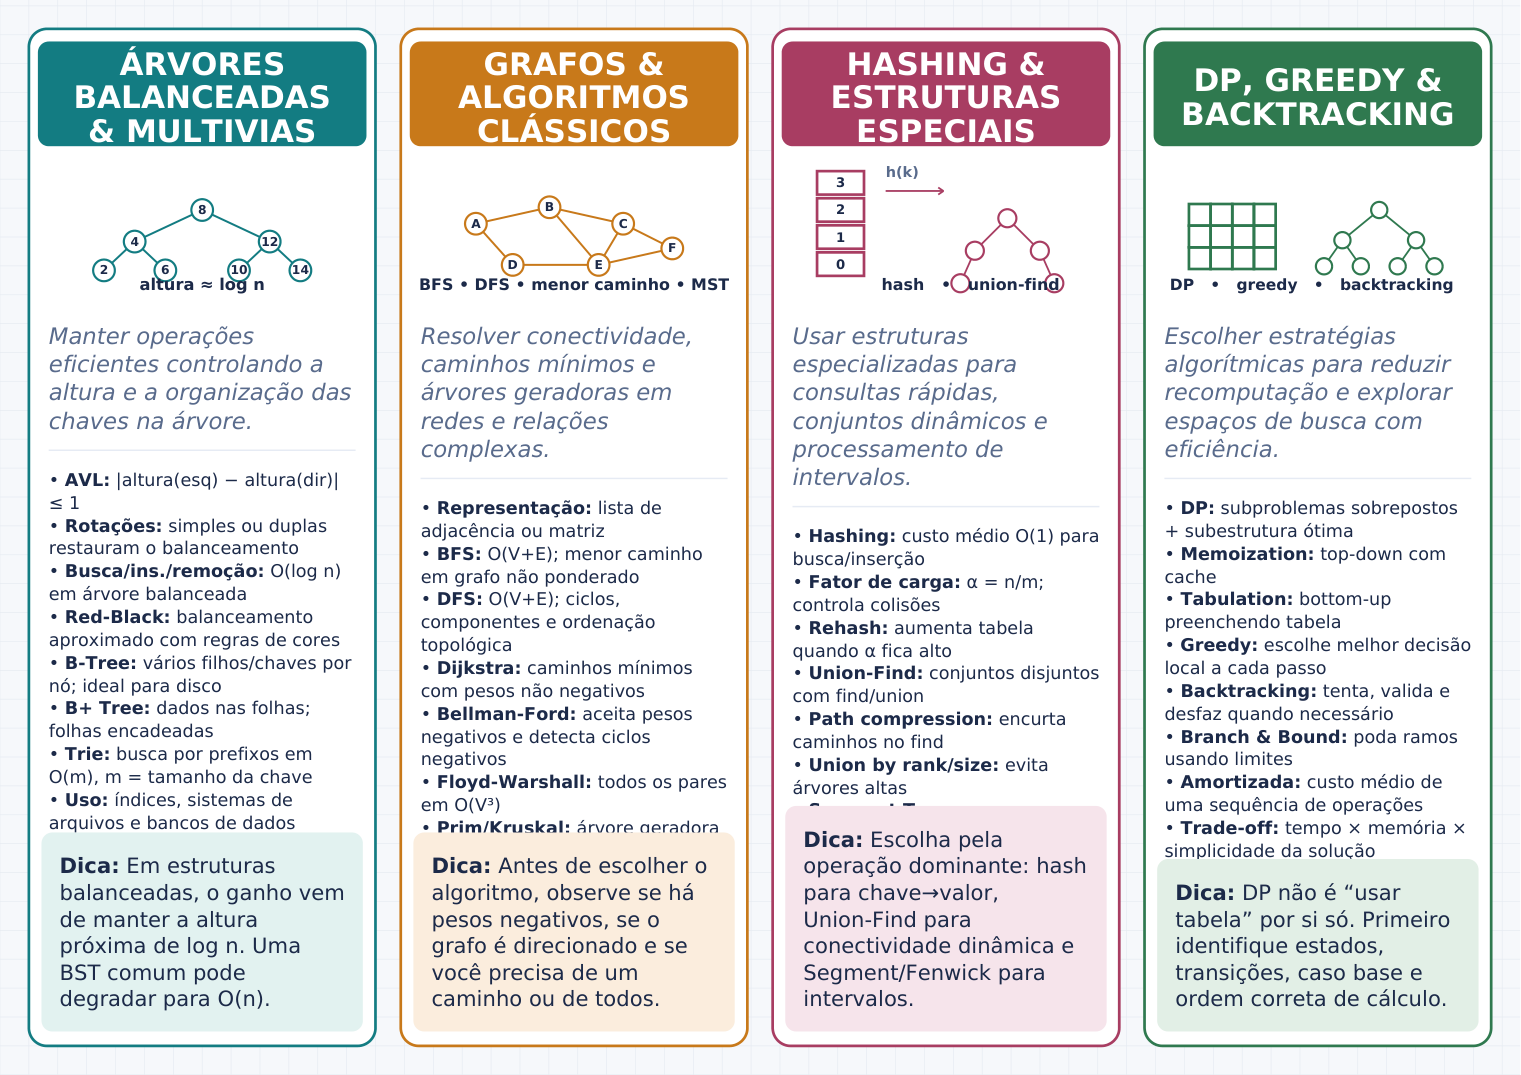

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Algoritmos_Estrutura_Dados_Avancado.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


In [3]:

import heapq
from collections import deque

print("=" * 60)
print("1) GRAFO - BFS (largura) e DFS (profundidade)")
grafo = {"A": ["B", "C"], "B": ["A", "D", "E"], "C": ["A", "F"],
         "D": ["B"], "E": ["B", "F"], "F": ["C", "E"]}
def bfs(g, inicio):
    vis, fila = [inicio], deque([inicio])
    while fila:
        v = fila.popleft()
        for nb in g[v]:
            if nb not in vis:
                vis.append(nb); fila.append(nb)
    return vis
def dfs(g, inicio):
    vis, pilha = [], [inicio]
    while pilha:
        v = pilha.pop()
        if v not in vis:
            vis.append(v); pilha.extend(nb for nb in g[v] if nb not in vis)
    return vis
print(f"   BFS: {bfs(grafo, 'A')}")
print(f"   DFS: {dfs(grafo, 'A')}")

print("\n2) DIJKSTRA: menor caminho (custo) no grafo ponderado")
g = {"A": [("B", 4), ("C", 2)], "B": [("C", 1), ("D", 5)],
     "C": [("D", 8), ("E", 10)], "D": [("E", 2)], "E": []}
def dijkstra(g, inicio):
    dist = {v: float("inf") for v in g}
    dist[inicio] = 0
    pq = [(0, inicio)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]: continue
        for v, w in g[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return dist
d = dijkstra(g, "A")
print(f"   distancias de A: {d}")

print("\n3) UNION-FIND (conjuntos disjuntos)")
pai = {}
def find(x):
    if pai[x] != x: pai[x] = find(pai[x])
    return pai[x]
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb: pai[rb] = ra
for x in "ABCDEFG": pai[x] = x
union("A", "B"); union("B", "C"); union("D", "E")
print(f"   A e C conectados? {find('A') == find('C')} | D e F? {find('D') == find('F')}")

print("\n4) PROGRAMACAO DINAMICA: mochila 0/1")
itens = [(60, 10), (100, 20), (120, 30)]  # (valor, peso)
capacidade = 50
dp = [[0]*(capacidade + 1) for _ in range(len(itens) + 1)]
for i in range(1, len(itens) + 1):
    v, p = itens[i-1]
    for c in range(capacidade + 1):
        dp[i][c] = dp[i-1][c]
        if p <= c:
            dp[i][c] = max(dp[i][c], dp[i-1][c - p] + v)
print(f"   valor maximo na mochila = {dp[-1][-1]}")

print("\n5) GREEDY: troco minimo com moedas")
moedas = [100, 50, 25, 10, 5, 1]
def troco(valor):
    usadas = []
    for m in moedas:
        while valor >= m:
            valor -= m; usadas.append(m)
    return usadas
print(f"   troco de 289: {troco(289)}")

print("\n6) HEAP: fila de prioridade")
h = []
for x in (7, 2, 9, 1, 5):
    heapq.heappush(h, x)
print(f"   removendo em ordem: {[heapq.heappop(h) for _ in range(len(h))]}")
print("\nOK - algoritmos avancados demonstrados.")


1) GRAFO - BFS (largura) e DFS (profundidade)
   BFS: ['A', 'B', 'C', 'D', 'E', 'F']
   DFS: ['A', 'C', 'F', 'E', 'B', 'D']

2) DIJKSTRA: menor caminho (custo) no grafo ponderado
   distancias de A: {'A': 0, 'B': 4, 'C': 2, 'D': 9, 'E': 11}

3) UNION-FIND (conjuntos disjuntos)
   A e C conectados? True | D e F? False

4) PROGRAMACAO DINAMICA: mochila 0/1
   valor maximo na mochila = 220

5) GREEDY: troco minimo com moedas
   troco de 289: [100, 100, 50, 25, 10, 1, 1, 1, 1]

6) HEAP: fila de prioridade
   removendo em ordem: [1, 2, 5, 7, 9]

OK - algoritmos avancados demonstrados.


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
